<a href="https://colab.research.google.com/github/Katyayini-Sharma/Celebal-Internship-2026/blob/main/week4_Katyayini_Sharma_CIFAR10_ANN_CNN_Learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2896s 17us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

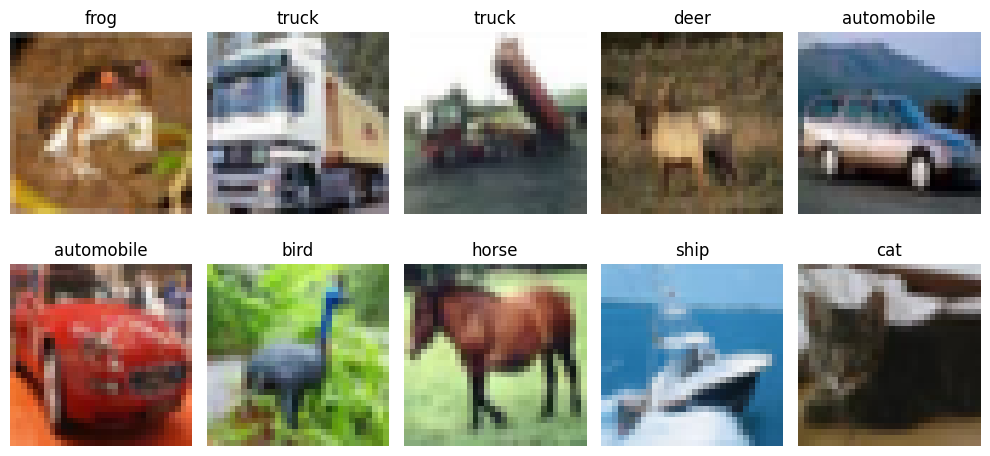

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.2677 - loss: 1.9950 - val_accuracy: 0.3300 - val_loss: 1.8647
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3108 - loss: 1.8741 - val_accuracy: 0.3506 - val_loss: 1.8058
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.3286 - loss: 1.8276 - val_accuracy: 0.3294 - val_loss: 1.8250
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.3450 - loss: 1.7951 - val_accuracy: 0.3896 - val_loss: 1.7326
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3487 - loss: 1.7806 - val_accuracy: 0.3814 - val_loss: 1.7399
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.3555 - loss: 1.7657 - val_accuracy: 0.3830 - val_loss: 1.7255
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3619 - loss: 1.7486 - val_accuracy: 0.4032 - val_loss: 1.6954
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.3665 - loss: 1.7324 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4245 - loss: 1.6361
ANN Test Accuracy: 0.4244999885559082


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 109ms/step - accuracy: 0.4733 - loss: 1.4801 - val_accuracy: 0.5368 - val_loss: 1.2943
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 108ms/step - accuracy: 0.6150 - loss: 1.1051 - val_accuracy: 0.5484 - val_loss: 1.2742
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 107ms/step - accuracy: 0.6746 - loss: 0.9334 - val_accuracy: 0.6824 - val_loss: 0.9039
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 108ms/step - accuracy: 0.7172 - loss: 0.8145 - val_accuracy: 0.5644 - val_loss: 1.2905
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 106ms/step - accuracy: 0.7425 - loss: 0.7340 - val_accuracy: 0.7360 - val_loss: 0.7941
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 109ms/step - accuracy: 0.7725 - loss: 0.6502 - val_accuracy: 0.7132 - val_loss: 0.8457
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 107ms/step - accuracy: 0.7923 - loss: 0.5806 - val_accuracy: 0.7180 - val_loss: 0.8487
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 108ms/step - accuracy: 0.8128 - loss: 0

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7088 - loss: 0.9746
CNN Test Accuracy: 0.7088000178337097


## 📈 Compare Learning Curves

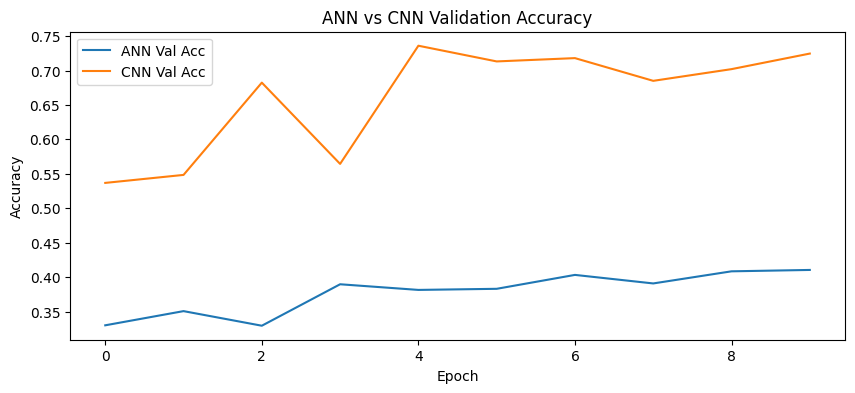

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4245
1,CNN,0.7088


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

1.Increase ANN layers and observe performance


In [12]:
deep_ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

deep_ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deep_ann_history = deep_ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

deep_ann_test_loss, deep_ann_test_acc = deep_ann_model.evaluate(x_test_flat, y_test)
print("Deeper ANN Test Accuracy:", deep_ann_test_acc)
print("Baseline ANN Test Accuracy:", ann_test_acc)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 59ms/step - accuracy: 0.2506 - loss: 2.0215 - val_accuracy: 0.3098 - val_loss: 1.8891
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - accuracy: 0.3116 - loss: 1.8851 - val_accuracy: 0.3388 - val_loss: 1.8370
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 58ms/step - accuracy: 0.3227 - loss: 1.8451 - val_accuracy: 0.3674 - val_loss: 1.7809
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - accuracy: 0.3337 - loss: 1.8190 - val_accuracy: 0.3720 - val_loss: 1.7690
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.3451 - loss: 1.7887 - val_accuracy: 0.3700 - val_loss: 1.7690
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 59ms/step - accuracy: 0.3537 - loss: 1.7698 - val_accuracy: 0.3902 - val_loss: 1.7267
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - accuracy: 0.3681 - loss: 1.7419 - val_accuracy: 0.3830 - val_loss: 1.7143
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 59ms/step - accuracy: 0.3697 - loss: 1.7276 - 

2: Change CNN filters from 32→64→128

In [13]:
deep_cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

deep_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deep_cnn_history = deep_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

deep_cnn_test_loss, deep_cnn_test_acc = deep_cnn_model.evaluate(x_test_norm, y_test)
print("Deeper CNN (32->64->128->256) Test Accuracy:", deep_cnn_test_acc)
print("Baseline CNN Test Accuracy:", cnn_test_acc)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 168s 232ms/step - accuracy: 0.4603 - loss: 1.5139 - val_accuracy: 0.5670 - val_loss: 1.2099
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 201s 231ms/step - accuracy: 0.6215 - loss: 1.0880 - val_accuracy: 0.6428 - val_loss: 0.9998
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 203s 232ms/step - accuracy: 0.6982 - loss: 0.8726 - val_accuracy: 0.6864 - val_loss: 0.8943
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 162s 230ms/step - accuracy: 0.7440 - loss: 0.7395 - val_accuracy: 0.6870 - val_loss: 0.9500
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 203s 232ms/step - accuracy: 0.7836 - loss: 0.6255 - val_accuracy: 0.7256 - val_loss: 0.8077
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 162s 230ms/step - accuracy: 0.8177 - loss: 0.5291 - val_accuracy: 0.5934 - val_loss: 1.3766
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 164s 232ms/step - accuracy: 0.8409 - loss: 0.4582 - val_accuracy: 0.7718 - val_loss: 0.7087
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 163s 231ms/step - accuracy: 0.8699 -

3 & 4: Increase epochs to 20 and Add EarlyStopping

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_model_v2 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_v2_history = cnn_model_v2.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

cnn_v2_test_loss, cnn_v2_test_acc = cnn_model_v2.evaluate(x_test_norm, y_test)
print("CNN (20 epochs + EarlyStopping) Test Accuracy:", cnn_v2_test_acc)
print("Training actually ran for", len(cnn_v2_history.history['loss']), "epochs")


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 109ms/step - accuracy: 0.4540 - loss: 1.5161 - val_accuracy: 0.5398 - val_loss: 1.2618
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 112ms/step - accuracy: 0.6048 - loss: 1.1313 - val_accuracy: 0.5360 - val_loss: 1.2767
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 109ms/step - accuracy: 0.6650 - loss: 0.9638 - val_accuracy: 0.5226 - val_loss: 1.4680
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 110ms/step - accuracy: 0.7103 - loss: 0.8328 - val_accuracy: 0.7014 - val_loss: 0.8543
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 109ms/step - accuracy: 0.7386 - loss: 0.7446 - val_accuracy: 0.6698 - val_loss: 1.0239
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 108ms/step - accuracy: 0.7665 - loss: 0.6649 - val_accuracy: 0.7266 - val_loss: 0.8061
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 109ms/step - accuracy: 0.7902 - loss: 0.5928 - val_accuracy: 0.6902 - val_loss: 0.9911
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 109ms/step - accuracy: 0.8141 - loss: 0

5: Add data augmentation training

In [15]:
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 83ms/step - accuracy: 0.3698 - loss: 1.7265 - val_accuracy: 0.4764 - val_loss: 1.4619
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 59s 84ms/step - accuracy: 0.4724 - loss: 1.4706 - val_accuracy: 0.5504 - val_loss: 1.2612
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 81ms/step - accuracy: 0.5086 - loss: 1.3755 - val_accuracy: 0.5880 - val_loss: 1.1696
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 82ms/step - accuracy: 0.5299 - loss: 1.3223 - val_accuracy: 0.5676 - val_loss: 1.2081
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 81ms/step - accuracy: 0.5478 - loss: 1.2821 - val_accuracy: 0.5928 - val_loss: 1.1561
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 81ms/step - accuracy: 0.5576 - loss: 1.2551 - val_accuracy: 0.6166 - val_loss: 1.1016
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 84ms/step - accuracy: 0.5660 - loss: 1.2220 - val_accuracy: 0.6378 - val_loss: 1.0351
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 81ms/step - accuracy: 0.5754 - loss: 1.2057 - 

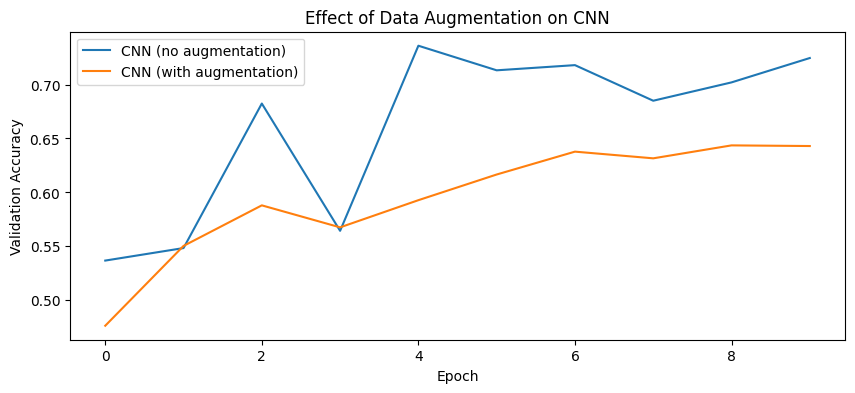

In [16]:
plt.figure(figsize=(10,4))
plt.plot(cnn_history.history['val_accuracy'], label='CNN (no augmentation)')
plt.plot(aug_history.history['val_accuracy'], label='CNN (with augmentation)')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Effect of Data Augmentation on CNN")
plt.legend()
plt.show()


In [17]:
final_comparison = pd.DataFrame({
    "Model": [
        "ANN (baseline)",
        "CNN (baseline)",
        "Deeper ANN (Task 1)",
        "Deeper CNN 32->64->128->256 (Task 2)",
        "CNN 20 epochs + EarlyStopping (Task 3 & 4)",
        "Augmented CNN (Task 5)"
    ],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        deep_ann_test_acc,
        deep_cnn_test_acc,
        cnn_v2_test_acc,
        aug_test_acc
    ]
})
final_comparison.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)


,Model,Test Accuracy
0,Deeper CNN 32->64->128->256 (Task 2),0.7436
1,CNN 20 epochs + EarlyStopping (Task 3 & 4),0.7253
2,CNN (baseline),0.7088
3,Augmented CNN (Task 5),0.6364
4,ANN (baseline),0.4245
5,Deeper ANN (Task 1),0.4216


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**